# Half-with-subs graph demo

Walks through how [`features.build_graphs_subs.build_half_subs_graph`](../../features/build_graphs_subs.py) turns one row of [`data/processed/lineup_snapshots_half_subs.parquet`](../../data/processed/) into the PyG `Data` object the [`HalfSubsGNN`](../../models/gnn_subs.py) consumes.

Per row of the parquet (one `(match, half, focal_team)` snapshot) the builder produces a graph with:

* **Variable node count** - 11 starters + however many subs appeared in this half (typically 3 - 6, up to 11).
* **Node features** - categorical (position OR archetype index) + 5-d numeric block (`is_starter`, `duration`, `start_min`, `end_min`, `was_subbed_off`) + template `(x, y)` + optional 10-d season-stat block.
* **Three edge types**, all carrying the same `edge_attr` schema with type-specific cells set to 0 outside the type they apply to:
    1. **Formation** - starter template adjacency, plus sub-inherited copies (each sub picks up the formation neighbors of whoever they replaced).
    2. **Sub** - bidirectional sub <-> replaced-starter edges, carrying `sub_minute` and a `same_position` flag.
    3. **Matchup** *(paired mode only)* - every cross-team pair whose on-pitch intervals overlap, weighted by `overlap_fraction` (shared minutes / half duration).

Drawing helpers live in [`../visualize_half_subs.py`](../visualize_half_subs.py); this notebook just loads a row, builds, prints, and renders.

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

# Make repo root importable when running from graphs/notebooks/.
ROOT = Path.cwd().resolve()
while not (ROOT / 'features' / 'build_graphs_subs.py').exists():
    if ROOT == ROOT.parent:
        raise RuntimeError('repo root not found')
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from features.build_graphs_subs import build_half_subs_graph
from features.vocab import ARCHETYPE_VOCAB, POSITION_VOCAB
from graphs.visualize_half_subs import (
    draw_paired_graph,
    draw_single_team_graph,
    legend_handles,
)

df = pd.read_parquet(ROOT / 'data' / 'processed' / 'train_snapshots_half_subs.parquet')
len(df), df.columns[:14].tolist()

(15362,
 ['match_id',
  'season',
  'half',
  'period_start_min',
  'period_end_min',
  'period_duration_min',
  'team1_team_id',
  'team2_team_id',
  'team1_formation',
  'team1_player_1',
  'team1_position_1',
  'team1_archetype_1',
  'team1_starter_duration_1',
  'team1_starter_p1_shots_per_90'])

## Pick a row

Filtering to a half that actually had a few subs makes the sub-edges visible. Adjust the predicate to look at any row you like - `match_id`, `half`, formation, etc.

In [2]:
# Pick a half-row with a meaningful number of subs (sub slot 5 filled = at least 5 subs).
mask = df['team1_sub_player_5'].notna() & df['team2_sub_player_3'].notna()
row = df[mask].iloc[0]
dict(row[['match_id', 'half', 'team1_formation', 'team2_formation',
          'team1_is_home', 'period_duration_min',
          'team1_xg', 'team2_xg', 'xg_team1_minus_team2_per_30']])

{'match_id': np.int64(5375213),
 'half': np.int64(2),
 'team1_formation': '4-3-3',
 'team2_formation': '4-4-2',
 'team1_is_home': np.True_,
 'period_duration_min': np.float64(50.0),
 'team1_xg': np.float64(0.34336),
 'team2_xg': np.float64(0.52799),
 'xg_team1_minus_team2_per_30': np.float64(-0.11077799999999997)}

## Build a single-team graph

`mode='single'` returns a 2-tuple `(team1_graph, team2_graph)` - same builder, just called once per side. Each side's graph is self-contained: formation edges + sub edges, no cross-team edges.

In [3]:
d1, d2 = build_half_subs_graph(row, mode='single', kind='position', use_stats=True)
print(f'team1: {d1.x.size(0)} nodes, {d1.edge_index.size(1)} directed edges')
print(f'team2: {d2.x.size(0)} nodes, {d2.edge_index.size(1)} directed edges')

# Inspect the node feature block for team1.
import torch
node_table = pd.DataFrame({
    'idx': range(d1.x.size(0)),
    'label': [POSITION_VOCAB[int(c)] for c in d1.x],
    'is_starter': d1.x_num[:, 0].tolist(),
    'duration': d1.x_num[:, 1].tolist(),
    'start_min': d1.x_num[:, 2].tolist(),
    'end_min': d1.x_num[:, 3].tolist(),
    'was_subbed_off': d1.x_num[:, 4].tolist(),
})
node_table.round(3)

team1: 16 nodes, 240 directed edges
team2: 15 nodes, 210 directed edges


,idx,label,is_starter,duration,start_min,end_min,was_subbed_off
0,0,GK,1.0,1.000,0.000,1.000,0.0
1,1,LB,1.0,0.826,0.000,0.826,0.0
2,2,LCB,1.0,1.000,0.000,1.000,0.0
3,3,RCB,1.0,1.000,0.000,1.000,0.0
4,4,RB,1.0,0.796,0.000,0.796,0.0
5,5,CM,1.0,1.000,0.000,1.000,0.0
6,6,CDM,1.0,1.000,0.000,1.000,0.0
7,7,CM,1.0,0.678,0.000,0.678,0.0
8,8,LWF,1.0,0.746,0.000,0.746,0.0
9,9,ST,1.0,0.542,0.000,0.542,1.0


## Inspect the edge table

Each row is one directed edge. `edge_attr` layout:

| col | meaning |
|---|---|
| 0 | `same_team` (1 intra, 0 matchup) |
| 1 - 3 | `dist, dx, dy` in normalized template coords |
| 4 - 6 | edge-type one-hot (formation / sub / matchup) |
| 7 | `sub_minute` (sub edges only) |
| 8 | `same_position` (sub edges only) |
| 9 | `overlap_fraction` (matchup only) |
| 10 - 13 | stat-diff block, present iff `use_stats=True` |

In [4]:
TYPE_NAMES = ['formation', 'sub', 'matchup']
edges = pd.DataFrame({
    'src': d1.edge_index[0].tolist(),
    'dst': d1.edge_index[1].tolist(),
    'type': [TYPE_NAMES[int(d1.edge_attr[k, 4:7].argmax().item())]
             for k in range(d1.edge_index.size(1))],
    'dist': d1.edge_attr[:, 1].tolist(),
    'sub_minute': d1.edge_attr[:, 7].tolist(),
    'same_pos': d1.edge_attr[:, 8].tolist(),
})
# Show only sub-edges in this preview - those are the structurally novel ones.
edges[edges['type'] == 'sub'].round(3).head(20)

,src,dst,type,dist,sub_minute,same_pos
0,10,11,sub,0.000,0.542,0.0
1,11,10,sub,0.000,0.542,0.0
2,9,12,sub,0.354,0.542,0.0
3,12,9,sub,0.354,0.542,0.0


## Visualize each team's graph

Starters at template coords, subs offset slightly so they don't sit on top of who they replaced. Sub edges (orange) connect each sub to their starter; dashed = re-deployed (different template position), solid = same slot.

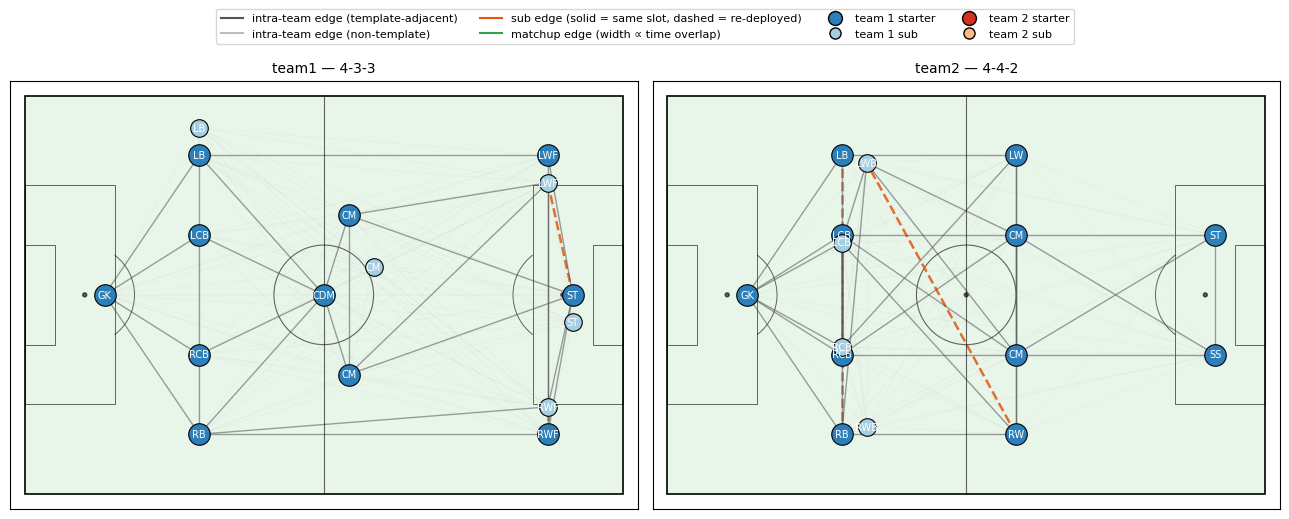

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
draw_single_team_graph(d1, ax=axes[0], vocab=POSITION_VOCAB,
                       title=f"team1 - {row['team1_formation']}")
draw_single_team_graph(d2, ax=axes[1], vocab=POSITION_VOCAB,
                       title=f"team2 - {row['team2_formation']}")
handles, labels = legend_handles()
fig.legend(handles, labels, loc='upper center', ncol=4, fontsize=8,
           bbox_to_anchor=(0.5, 1.02))
fig.tight_layout(); plt.show()

## Paired graph - adds time-overlap matchup edges

`mode='paired'` returns a single joint graph (team1 + team2 nodes, team2 coords rotated 180° about the pitch center so opposing players in the same channel sit near each other). Matchup edges (green) connect every cross-team pair whose on-pitch intervals overlap; line width is proportional to `overlap_fraction`.

Two starters who both played the whole half -> fat green line. A sub who came on at 80' against an opponent who came off at 75' -> no edge. A sub vs a sub with 5 minutes shared -> faint line. This temporal structure is what the per-half tabular models can't easily encode and is the main thing the GNN gets to learn from.

paired graph: 31 nodes, 880 directed edges


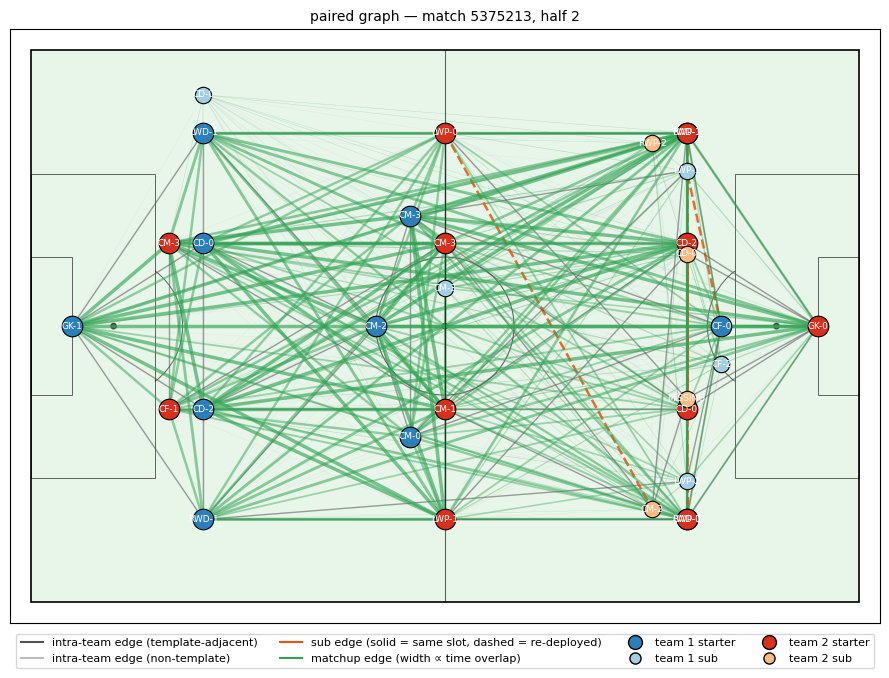

In [6]:
dp = build_half_subs_graph(row, mode='paired', kind='archetype', use_stats=True)
print(f'paired graph: {dp.x.size(0)} nodes, {dp.edge_index.size(1)} directed edges')

fig, ax = plt.subplots(figsize=(9, 6.5))
draw_paired_graph(dp, ax=ax, vocab=ARCHETYPE_VOCAB,
                  title=(f"paired graph - match {int(row['match_id'])}, "
                         f"half {int(row['half'])}"))
handles, labels = legend_handles()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=8,
           bbox_to_anchor=(0.5, -0.04))
fig.tight_layout(); plt.show()

## Edge-type breakdown for this half

How densely each edge type fills the graph. Matchup edges dominate the count because every cross-team overlap gets one; formation edges are the small fixed-template set; sub edges are the rarest but the structurally novel ones.

In [7]:
types = [TYPE_NAMES[int(dp.edge_attr[k, 4:7].argmax().item())]
         for k in range(dp.edge_index.size(1))]
pd.Series(types).value_counts().rename('directed edges').to_frame()

,directed edges
formation,440
matchup,430
sub,10
